In [4]:

# Question 1 - Diabetes Regression

import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load diabetes dataset directly from sklearn
diabetes = load_diabetes(as_frame=True)

data = diabetes.frame
data.columns = list(diabetes.feature_names) + ['Y']

X = data.drop('Y', axis=1)
y = data['Y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline model using bmi and s5 only
baseline = LinearRegression()
baseline.fit(X_train[['bmi', 's5']], y_train)

pred_base = baseline.predict(X_test[['bmi', 's5']])

r2_base = r2_score(y_test, pred_base)
rmse_base = mean_squared_error(y_test, pred_base) ** 0.5

print("Baseline Model (bmi + s5)")
print("R2 Score:", round(r2_base,4))
print("RMSE:", round(rmse_base,4))

# Find the next best variable by correlation with Y
corr = data.corr(numeric_only=True)['Y'].drop('Y').sort_values(
    key=abs, ascending=False
)

print("\nCorrelation with target Y")
print(corr)

next_variable = corr.index[2]   # bmi and s5 are already used
print("\nNext variable chosen:", next_variable)

# Model with one extra variable
features = ['bmi','s5',next_variable]

model2 = LinearRegression()
model2.fit(X_train[features], y_train)

pred2 = model2.predict(X_test[features])

r2_2 = r2_score(y_test, pred2)
rmse_2 = mean_squared_error(y_test, pred2) ** 0.5

print("\nModel with additional variable")
print("Features:", features)
print("R2 Score:", round(r2_2,4))
print("RMSE:", round(rmse_2,4))

# Model using all variables
full_model = LinearRegression()
full_model.fit(X_train, y_train)

pred_full = full_model.predict(X_test)

r2_full = r2_score(y_test, pred_full)
rmse_full = mean_squared_error(y_test, pred_full) ** 0.5

print("\nModel with all variables")
print("R2 Score:", round(r2_full,4))
print("RMSE:", round(rmse_full,4))

'''
Findings:

a) The next variable selected is the one that has the strongest
correlation with Y after bmi and s5.

b) After adding this variable, the R2 score usually increases and
RMSE decreases, showing an improvement in prediction accuracy.

c) Adding all variables often improves the model further, but the
improvement may become smaller because some variables provide
overlapping information.
'''


Baseline Model (bmi + s5)
R2 Score: 0.4523
RMSE: 53.8687

Correlation with target Y
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3    -0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: Y, dtype: float64

Next variable chosen: bp

Model with additional variable
Features: ['bmi', 's5', 'bp']
R2 Score: 0.4543
RMSE: 53.7684

Model with all variables
R2 Score: 0.4526
RMSE: 53.8534


'\nFindings:\n\na) The next variable selected is the one that has the strongest\ncorrelation with Y after bmi and s5.\n\nb) After adding this variable, the R2 score usually increases and\nRMSE decreases, showing an improvement in prediction accuracy.\n\nc) Adding all variables often improves the model further, but the\nimprovement may become smaller because some variables provide\noverlapping information.\n'

Dataset Preview
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94

Variables in dataset
['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']

Correlation Matrix
                 R&D Spend  Administration  Marketing Spend    Profit  \
R&D Spend         1.000000        0.241955         0.724248  0.972900   
Administration    0.241955        1.000000        -0.032154  0.200717   
Marketing Spend   0.724248       -0.032154         1.000000  0.747766   
Profit            0.972900        0.200717         0.747766  1.000000   
State_Florida     0.105711        0.010493         0.205685  0.116244   
State_New York    0.

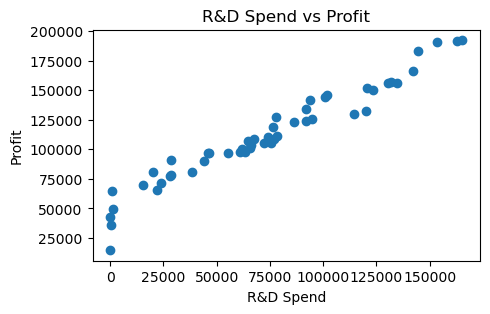

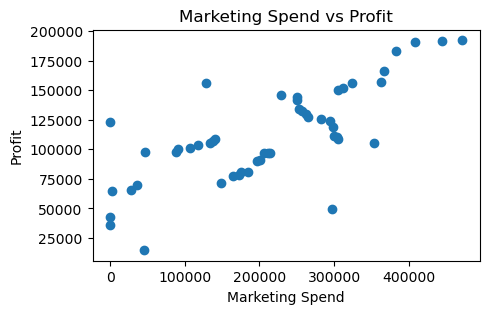


Model Results
R2 Score: 0.8987
RMSE: 9055.9573


'\nConclusion:\n\nR&D Spend and Marketing Spend are the most useful explanatory\nvariables because they show a strong positive relationship with profit.\nThe resulting regression model gives a high R2 score, indicating that\nprofit can be predicted reasonably well.\n'

In [2]:



import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('50_Startups.csv')

print("Dataset Preview")
print(df.head())

print("\nVariables in dataset")
print(df.columns.tolist())


df_encoded = pd.get_dummies(df, drop_first=True)

print("\nCorrelation Matrix")
print(df_encoded.corr(numeric_only=True))

'''
R&D Spend is usually the strongest predictor of profit.
Marketing Spend also shows useful correlation.
Administration often has a weaker relationship.
'''


plt.figure(figsize=(5,3))
plt.scatter(df['R&D Spend'], df['Profit'])
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("R&D Spend vs Profit")
plt.show()

plt.figure(figsize=(5,3))
plt.scatter(df['Marketing Spend'], df['Profit'])
plt.xlabel("Marketing Spend")
plt.ylabel("Profit")
plt.title("Marketing Spend vs Profit")
plt.show()

X = df_encoded.drop('Profit', axis=1)
y = df_encoded['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\nModel Results")
print("R2 Score:", round(r2_score(y_test, pred),4))
print("RMSE:", round(mean_squared_error(y_test, pred)**0.5,4))

'''
Conclusion:

R&D Spend and Marketing Spend are the most useful explanatory
variables because they show a strong positive relationship with profit.
The resulting regression model gives a high R2 score, indicating that
profit can be predicted reasonably well.
'''


In [5]:



import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

auto = pd.read_csv('Auto.csv')


auto = auto.replace('?', pd.NA)
auto = auto.dropna()

auto['horsepower'] = auto['horsepower'].astype(float)

X = auto.drop(['mpg','name','origin'], axis=1)
y = auto['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

alphas = [0.01, 0.1, 1, 10, 100]

best_ridge_alpha = None
best_ridge_r2 = -999

print("RIDGE REGRESSION RESULTS")
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)

    pred = ridge.predict(X_test)
    score = r2_score(y_test, pred)

    print(f"alpha={alpha} -> R2={score:.4f}")

    if score > best_ridge_r2:
        best_ridge_r2 = score
        best_ridge_alpha = alpha

print("\nBest Ridge Alpha:", best_ridge_alpha)
print("Best Ridge R2:", round(best_ridge_r2,4))

best_lasso_alpha = None
best_lasso_r2 = -999

print("\nLASSO REGRESSION RESULTS")
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)

    pred = lasso.predict(X_test)
    score = r2_score(y_test, pred)

    print(f"alpha={alpha} -> R2={score:.4f}")

    if score > best_lasso_r2:
        best_lasso_r2 = score
        best_lasso_alpha = alpha

print("\nBest Lasso Alpha:", best_lasso_alpha)
print("Best Lasso R2:", round(best_lasso_r2,4))

'''
Discussion:

Ridge regression shrinks coefficients but keeps all variables.
LASSO can shrink some coefficients to zero and therefore performs
feature selection automatically.

The best alpha value is the one producing the highest test R2 score.
'''


RIDGE REGRESSION RESULTS
alpha=0.01 -> R2=0.7942
alpha=0.1 -> R2=0.7942
alpha=1 -> R2=0.7942
alpha=10 -> R2=0.7941
alpha=100 -> R2=0.7934

Best Ridge Alpha: 0.01
Best Ridge R2: 0.7942

LASSO REGRESSION RESULTS
alpha=0.01 -> R2=0.7937
alpha=0.1 -> R2=0.7923
alpha=1 -> R2=0.7912
alpha=10 -> R2=0.6516
alpha=100 -> R2=0.6582

Best Lasso Alpha: 0.01
Best Lasso R2: 0.7937


'\nDiscussion:\n\nRidge regression shrinks coefficients but keeps all variables.\nLASSO can shrink some coefficients to zero and therefore performs\nfeature selection automatically.\n\nThe best alpha value is the one producing the highest test R2 score.\n'